In [1]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense

In [2]:
path_of_dir=os.listdir('../brain tumor/Brain Tumor Data Set/')
classes_in_dir={'Healthy':0,'Brain Tumor':1}

classes_in_dir

{'Healthy': 0, 'Brain Tumor': 1}

In [3]:
Y=[]
X=[]
for i in classes_in_dir:
    path='../brain tumor/Brain Tumor Data Set/'+i
    for j in os.listdir(path):
        pic=cv2.imread(path+'/'+j,1)
        pic=cv2.resize(pic,(200,200))
        X.append(pic)
        Y.append(classes_in_dir[i])


In [4]:
# Data augmentation for training
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # 20% for validation
)

# Train generator
train_generator = datagen.flow_from_directory(
    '../brain tumor/Brain Tumor Data Set/',               # single folder containing class subfolders
    target_size=(200, 200),
    color_mode='grayscale',  # 'rgb' if color images
    batch_size=32,
    class_mode='binary',
    subset='training'        # this is the training set
)
# Validation generator (no extra augmentation)
val_generator = datagen.flow_from_directory(
    '../brain tumor/Brain Tumor Data Set/',
    target_size=(200, 200),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary',
    subset='validation'      # this is the validation set
)

Found 3681 images belonging to 2 classes.
Found 919 images belonging to 2 classes.


In [5]:
x=np.array(X,dtype=np.uint8)
y=np.array(Y,dtype=np.uint8)
pd.Series(y).value_counts()

1    2513
0    2087
Name: count, dtype: int64

In [75]:
y.shape

(4600,)

In [76]:
x.shape

(4600, 200, 200, 3)

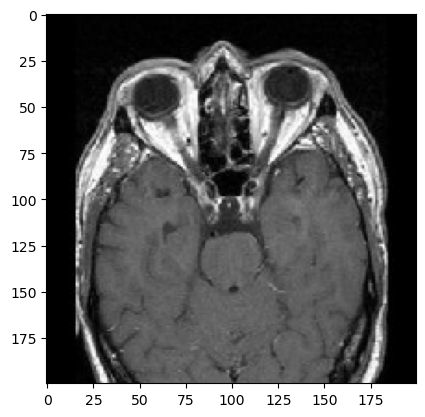

In [6]:
plt.imshow(x[1])


In [7]:
x.shape

(4600, 200, 200, 3)

In [8]:
x_3D=x.reshape(-1,200,200)
x_3D.shape

(13800, 200, 200)

In [9]:
x_3D.ndim

3

In [10]:
x_2D=x.reshape(len(x),-1)

In [11]:
x_2D.ndim

2

In [12]:
x_2D.shape

(4600, 120000)

In [13]:
x_2D.ndim

2

In [14]:
x_train3D,x_test3D,y_train3D,y_test3D=train_test_split(x,y,random_state=10,test_size=0.20)


In [15]:
x_train3D.shape

(3680, 200, 200, 3)

#CNN MODEL

In [16]:
cnn=tf.keras.models.Sequential([keras.layers.Input(shape=(200,200,3)),
Conv2D(filters=32, kernel_size=(5, 5), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1,activation='sigmoid') # output layer

])

cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 196, 196, 32)      2432      
                                                                 
 batch_normalization (BatchN  (None, 196, 196, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 98, 98, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 96, 96, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 96, 96, 64)       256       
 hNormalization)                                                 
                                                        

In [17]:
cnn.compile(keras.optimizers.Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
#train
cnn.fit(x_train3D,y_train3D, epochs=5, batch_size=32 ,validation_data=(x_test3D,y_test3D))

Epoch 1/5
115/115 [==============================] - 72s 617ms/step - loss: 0.5749 - accuracy: 0.8084 - val_loss: 0.3205 - val_accuracy: 0.8793
Epoch 2/5
115/115 [==============================] - 74s 643ms/step - loss: 0.1501 - accuracy: 0.9497 - val_loss: 0.2138 - val_accuracy: 0.9163
Epoch 3/5
115/115 [==============================] - 75s 653ms/step - loss: 0.0641 - accuracy: 0.9851 - val_loss: 0.1248 - val_accuracy: 0.9554
Epoch 4/5
115/115 [==============================] - 76s 657ms/step - loss: 0.0377 - accuracy: 0.9943 - val_loss: 0.1184 - val_accuracy: 0.9587
Epoch 5/5
115/115 [==============================] - 76s 660ms/step - loss: 0.0278 - accuracy: 0.9967 - val_loss: 0.1027 - val_accuracy: 0.9641


In [19]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=2)

29/29 - 5s - loss: 0.1027 - accuracy: 0.9641 - 5s/epoch - 157ms/step


In [20]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

29/29 [==============================] - 5s 156ms/step


In [21]:
accuracy_score(y_test3D,pred1)

0.9641304347826087

In [22]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(conf_mat)
print(classification_report(y_test3D,pred1))


[[391  25]
 [  8 496]]
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       416
           1       0.95      0.98      0.97       504

    accuracy                           0.96       920
   macro avg       0.97      0.96      0.96       920
weighted avg       0.96      0.96      0.96       920



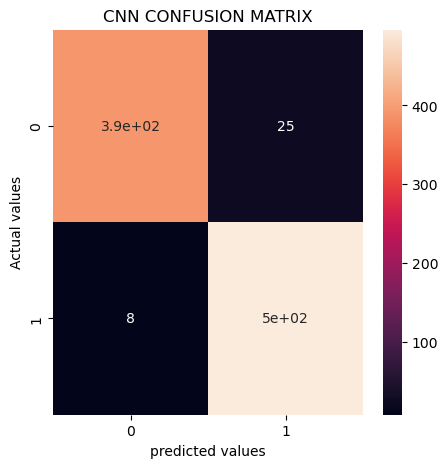

In [23]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [24]:
x_2D.shape

(4600, 120000)

In [25]:
x_train2D,x_test2D,y_train2D,y_test2D=train_test_split(x_2D,y,random_state=10,test_size=0.20)

In [26]:
x_train2D=x_train2D/255
x_test2D=x_test2D/255

In [27]:
x_train2D.shape

(3680, 120000)

In [28]:

rf=RandomForestClassifier()
rf.fit(x_train2D,y_train2D)

RandomForestClassifier()

In [29]:
pred2=rf.predict(x_test2D)

In [30]:
accuracy_score(y_test2D,pred2)

0.9652173913043478

In [31]:

conf_mat2=confusion_matrix(y_test2D,pred2)


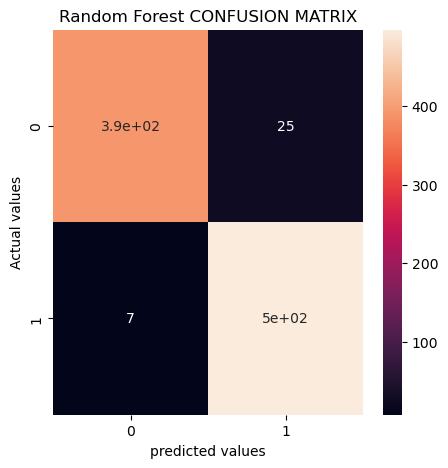

In [32]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [33]:
# SVM

svm= SVC(kernel='linear',random_state=32)
svm.fit(x_train2D,y_train2D)

SVC(kernel='linear', random_state=32)

In [34]:
pred3=svm.predict(x_test2D)

In [35]:
accuracy_score(y_test2D,pred3)

0.9532608695652174

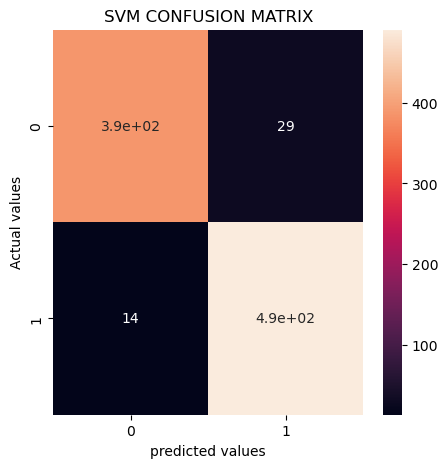

In [36]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [37]:
knn=KNeighborsClassifier()
knn.fit(x_train2D,y_train2D)

KNeighborsClassifier()

In [38]:
pred4=knn.predict(x_test2D)

In [39]:
#evaluting the model
accuracy_score(y_test2D,pred4)

0.883695652173913

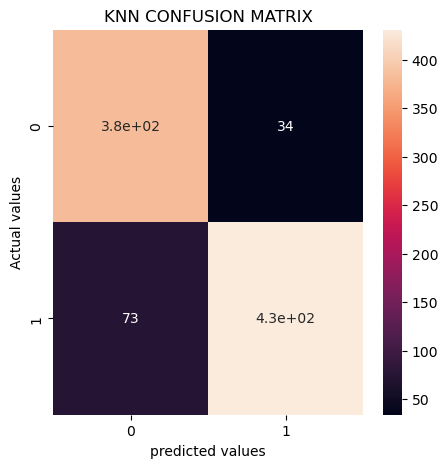

In [40]:
conf_mat4=confusion_matrix(y_test2D,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [41]:
LR = LogisticRegression(max_iter=1000, solver='lbfgs')
LR.fit(x_train2D, y_train2D)

LogisticRegression(max_iter=1000)

In [42]:
pred5 = LR.predict(x_test2D)

print("Accuracy:", accuracy_score(y_test2D, pred5))
print("\nClassification Report:\n", classification_report(y_test2D, pred5))

Accuracy: 0.9597826086956521

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95       416
           1       0.95      0.97      0.96       504

    accuracy                           0.96       920
   macro avg       0.96      0.96      0.96       920
weighted avg       0.96      0.96      0.96       920



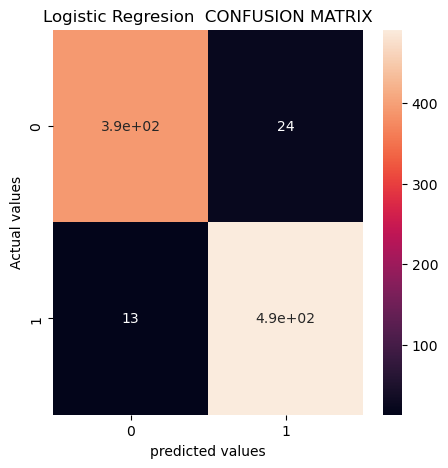

In [43]:
conf_mat5= confusion_matrix(y_test2D,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

Text(0.5, 0, '1')

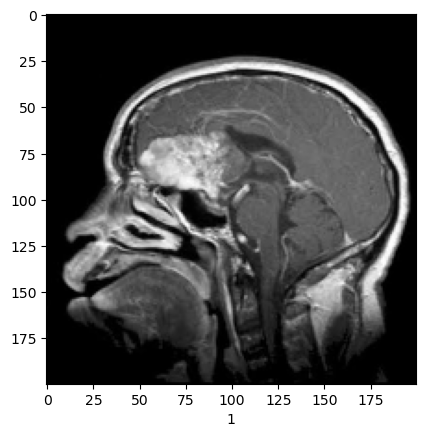

In [44]:
w=plt.imshow(x_test3D[50] ,cmap='gray')
plt.xlabel(y_test3D[50])

In [45]:
f=np.where(y_test3D != pred1)[0]

In [46]:
print(f)

[  1  35  55  87 162 211 245 325 349 381 382 405 459 472 475 488 498 505
 515 541 641 677 717 752 774 778 779 801 805 816 855 861 864]


In [47]:
print("Y_test =",y_test2D[103])

Y_test = 1


In [48]:
print("CNN =",pred1[103])

CNN = 1


In [49]:
print("RF =",pred2[103])

RF = 1


In [50]:
print("SVM =",pred3[103])

SVM = 1


In [51]:
print("KNN =",pred4[103])

KNN = 1


In [52]:
print("LR =",pred5[103])

LR = 1


# ALL PREDICTED VALUES

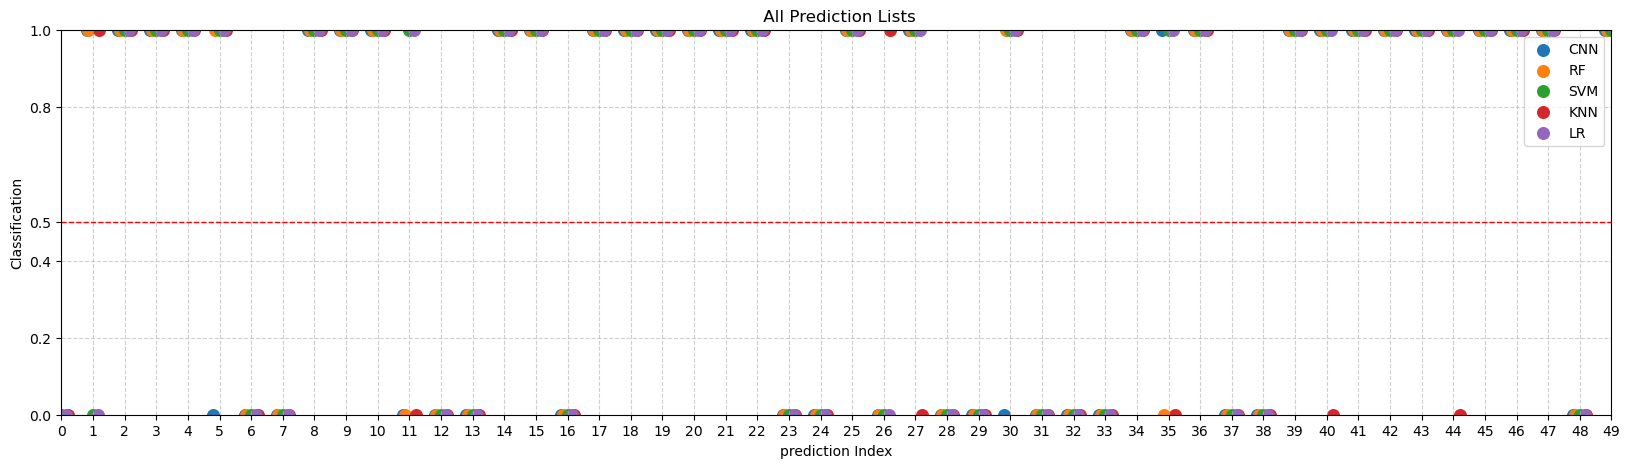

In [53]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


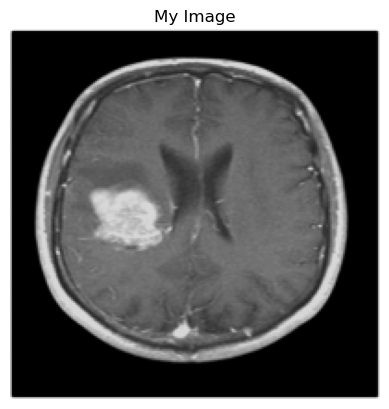

In [54]:
# Path to image
img_path = r"D:\My Final Work\external_pic\1.jpg"  # use raw string to avoid \n errors

# Read image
check_img = cv2.imread(img_path,1)
check_img=cv2.resize(check_img,(200,200))
# Show image
plt.imshow(check_img)
plt.axis('off')  # Hide axis numbers
plt.title("My Image")
plt.show()


In [55]:
outside_img =cv2.resize(check_img,(200,200))

In [56]:
outside_img.shape

(200, 200, 3)

In [57]:
cnnpred1=outside_img.reshape(1,200,200,3)
cnnpred=cnnpred1/255

In [58]:
cnnpred.shape

(1, 200, 200, 3)

In [59]:
cnnpred.ndim

4

In [60]:
p1=(cnn.predict(cnnpred)>0.5).astype('int').flatten()

1/1 [==============================] - 0s 312ms/step


In [61]:
print(p1)

[1]


# below is for 2D arrays

In [62]:
p_2D=outside_img.reshape(1, -1)
p_2D.shape

(1, 120000)

In [63]:
p_2D.ndim

2

In [64]:
p_2D=p_2D/255

In [65]:
p2=rf.predict(p_2D)

In [66]:
print(p2)

[1]


In [67]:
p3=svm.predict(p_2D)

In [68]:
print(p3)

[0]


In [69]:
p4=LR.predict(p_2D)

In [70]:
print(p4)

[0]


In [71]:
p5=knn.predict(p_2D)

In [72]:
print(p5)

[0]


In [73]:
if(p1+p2+p3+p4+p5 >= 3):
    print("Tumor")
else:
    print("No Tumor")


No Tumor
